In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [3]:
img_bgr = cv2.imread("./images/image0.jpeg")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

In [4]:
gx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)

In [5]:
mag = np.sqrt(gx**2 + gy**2)
# Orientation in radians, often used as the 'Hue' in edge visualization
orientation = np.arctan2(gy, gx)

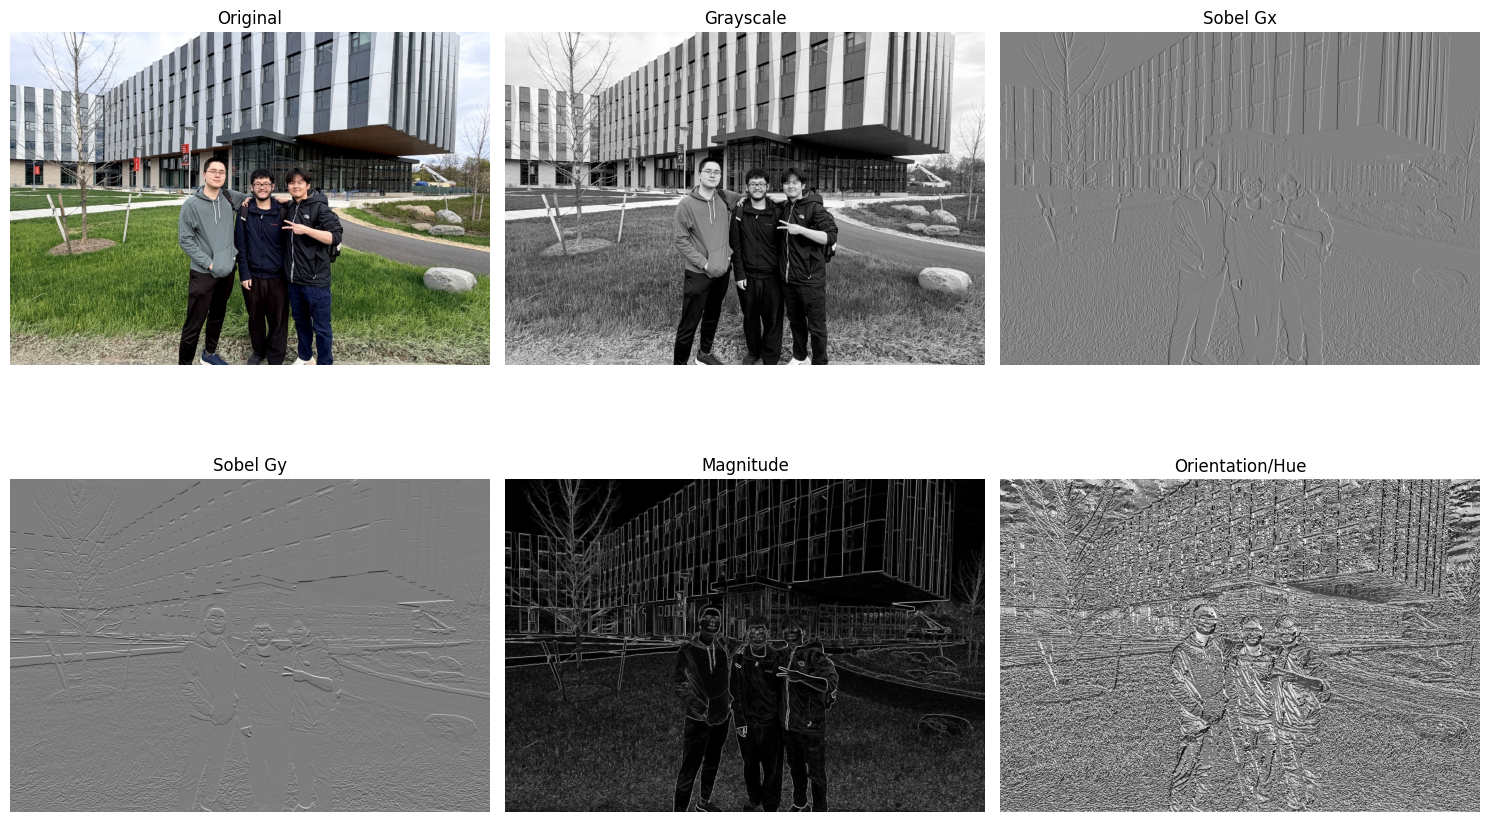

In [6]:
titles = ['Original', 'Grayscale', 'Sobel Gx', 'Sobel Gy', 'Magnitude', 'Orientation/Hue']
images = [img_rgb, img_gray, gx, gy, mag, orientation]

plt.figure(figsize=(15, 10))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray' if i > 0 else None)
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# 6. Save the final Magnitude image
# Normalize to 0-255 first
mag_final = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


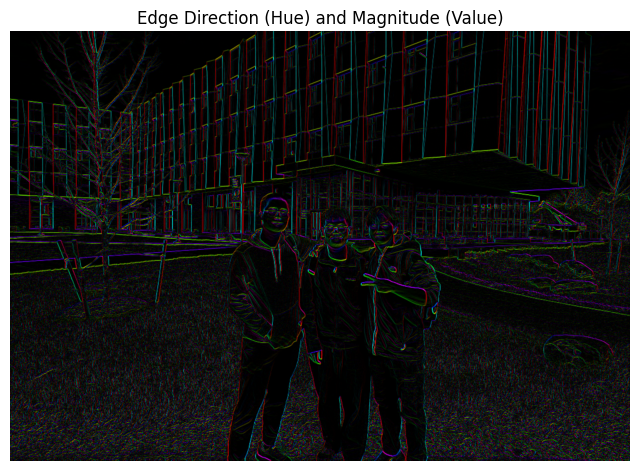

In [7]:
hue = ((orientation + np.pi) / (2 * np.pi) * 180).astype(np.uint8)

# 2. Normalize magnitude to [0, 255] for the Value channel
val = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# 3. Create a Saturation channel (full saturation)
sat = np.full_like(hue, 255)

# 4. Merge into an HSV image and convert to BGR/RGB for display
hsv_combined = cv2.merge([hue, sat, val])
rgb_combined = cv2.cvtColor(hsv_combined, cv2.COLOR_HSV2RGB)

# Display the result
plt.figure(figsize=(8, 8))
plt.imshow(rgb_combined)
plt.title('Edge Direction (Hue) and Magnitude (Value)')
plt.axis('off')
plt.show()